<a href="https://colab.research.google.com/github/julipolovinkina-hub/ALGORITMIZATSITA/blob/main/2laba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. ГРАФЫ
Матрица смежности:
  [0, 1, 0, 0, 0, 0]
  [1, 0, 1, 0, 0, 0]
  [0, 1, 0, 1, 0, 0]
  [0, 0, 1, 0, 1, 0]
  [0, 0, 0, 1, 0, 1]
  [0, 0, 0, 0, 1, 0]

Матрица инцидентности:
  [1, 0, 0, 0, 0]
  [1, 1, 0, 0, 0]
  [0, 1, 1, 0, 0]
  [0, 0, 1, 1, 0]
  [0, 0, 0, 1, 1]
  [0, 0, 0, 0, 1]

Компоненты связности: [[1, 2, 3, 4, 5, 6]]

[Открывается окно визуализации графа]


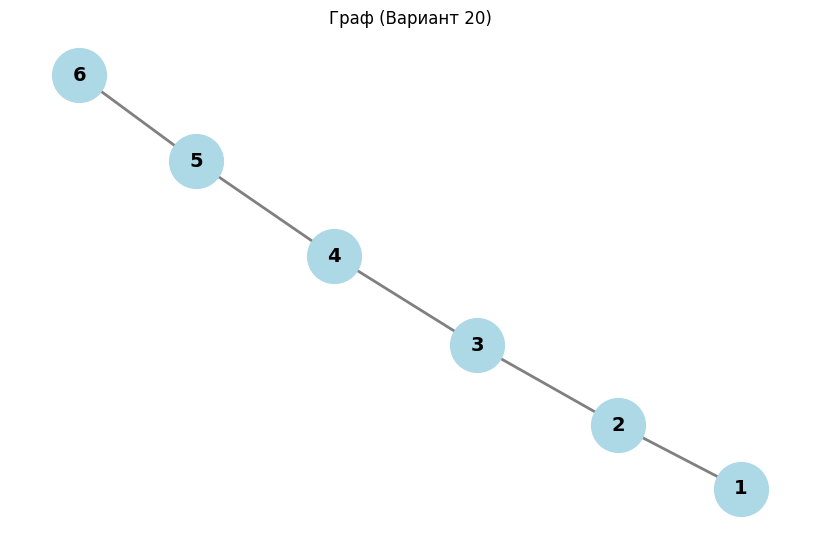


2. БИНАРНОЕ ДЕРЕВО ПОИСКА (BST)
Исходное дерево (in-order): [9, 12, 15, 18, 20, 23, 27]
Поиск элемента 15: Найден
Удаление элемента 23...
Дерево после удаления: [9, 12, 15, 18, 20, 27]

3. ПИРАМИДАЛЬНАЯ СОРТИРОВКА (Heap Sort)
Исходный массив:        [18, 12, 23, 9, 15, 20, 27]
Отсортированный массив: [9, 12, 15, 18, 20, 23, 27]


In [2]:
# Лабораторная работа 2
# Задание №20
# Выполнила: Половинкина Ю. С.
# Группа: ЦИБ-251

import networkx as nx                     # библиотека для работы с графами
import matplotlib.pyplot as plt           # библиотека для визуализации

class Graph:
    def __init__(self, vertices: list[int], edges: list[tuple[int, int]]) -> None:
        self.vertices: list[int] = vertices           # список вершин
        self.edges: list[tuple[int, int]] = edges     # список ребер
        self.adj_matrix: list[list[int]] = self._build_adj_matrix()   # матрица смежности
        self.inc_matrix: list[list[int]] = self._build_inc_matrix()   # матрица инцидентности

    def _build_adj_matrix(self) -> list[list[int]]:
        n: int = len(self.vertices)                   # количество вершин
        matrix: list[list[int]] = [[0] * n for _ in range(n)]  # создание матрицы NxN
        for u, v in self.edges:                       # O(E) - проход по ребрам
            matrix[u - 1][v - 1] = 1                  # заполнение симметрично
            matrix[v - 1][u - 1] = 1                  # граф неориентированный
        return matrix

    def _build_inc_matrix(self) -> list[list[int]]:
        n: int = len(self.vertices)                   # количество вершин
        m: int = len(self.edges)                      # количество ребер
        matrix: list[list[int]] = [[0] * m for _ in range(n)]  # матрица NxM
        for j, (u, v) in enumerate(self.edges):       # O(E) - проход по ребрам
            matrix[u - 1][j] = 1                      # вершина u инцидентна ребру j
            matrix[v - 1][j] = 1                      # вершина v инцидентна ребру j
        return matrix

    def find_connected_components(self) -> list[list[int]]:
        visited: set[int] = set()                     # множество посещенных вершин
        components: list[list[int]] = []              # список компонент связности

        def dfs(v: int, component: list[int]) -> None:
            visited.add(v)                            # помечаем вершину как посещенную
            component.append(v)                       # добавляем в текущую компоненту
            for neighbor, is_connected in enumerate(self.adj_matrix[v - 1]):  # O(V)
                if is_connected and (neighbor + 1) not in visited:
                    dfs(neighbor + 1, component)      # рекурсивный обход

        for v in self.vertices:                       # O(V)
            if v not in visited:                      # если вершина не посещена
                component: list[int] = []
                dfs(v, component)                     # запускаем DFS
                components.append(component)
        return components                             # O(V + E) в сумме

    def visualize(self) -> None:
        G: nx.Graph = nx.Graph()                      # создание объекта графа networkx
        G.add_nodes_from(self.vertices)               # добавление вершин
        G.add_edges_from(self.edges)                  # добавление ребер

        plt.figure(figsize=(8, 5))                    # размер окна
        pos = nx.spring_layout(G, seed=42)            # расположение вершин
        nx.draw(G, pos, with_labels=True, node_color='lightblue',
                node_size=1500, font_size=14, font_weight='bold',
                edge_color='gray', width=2)           # отрисовка графа
        plt.title("Граф (Вариант 20)")                # заголовок
        plt.show()                                    # показ окна


class TreeNode:
    def __init__(self, key: int) -> None:
        self.key: int = key                           # значение узла
        self.left: TreeNode | None = None             # левый потомок
        self.right: TreeNode | None = None            # правый потомок


class BST:
    def __init__(self) -> None:
        self.root: TreeNode | None = None             # корень дерева

    def insert(self, key: int) -> None:
        if self.root is None:                         # если дерево пустое
            self.root = TreeNode(key)
        else:
            self._insert_recursive(self.root, key)

    def _insert_recursive(self, node: TreeNode, key: int) -> None:
        if key < node.key:                            # идем влево
            if node.left is None:
                node.left = TreeNode(key)
            else:
                self._insert_recursive(node.left, key)
        elif key > node.key:                          # идем вправо
            if node.right is None:
                node.right = TreeNode(key)
            else:
                self._insert_recursive(node.right, key)

    def search(self, key: int) -> TreeNode | None:
        return self._search_recursive(self.root, key)

    def _search_recursive(self, node: TreeNode | None, key: int) -> TreeNode | None:
        if node is None or node.key == key:           # граничный случай или нашли
            return node
        if key < node.key:
            return self._search_recursive(node.left, key)
        return self._search_recursive(node.right, key)

    def delete(self, key: int) -> None:
        self.root = self._delete_recursive(self.root, key)

    def _delete_recursive(self, node: TreeNode | None, key: int) -> TreeNode | None:
        if node is None:
            return node

        if key < node.key:
            node.left = self._delete_recursive(node.left, key)
        elif key > node.key:
            node.right = self._delete_recursive(node.right, key)
        else:
            if node.left is None:                     # случай 1: нет левого потомка
                return node.right
            elif node.right is None:                  # случай 2: нет правого потомка
                return node.left

            # случай 3: два потомка, ищем минимальный в правом поддереве
            temp: TreeNode = self._min_value_node(node.right)
            node.key = temp.key                       # заменяем значение
            node.right = self._delete_recursive(node.right, temp.key)
        return node

    def _min_value_node(self, node: TreeNode) -> TreeNode:
        current: TreeNode = node
        while current.left is not None:               # идем максимально влево
            current = current.left
        return current

    def inorder(self) -> list[int]:
        result: list[int] = []
        self._inorder_recursive(self.root, result)
        return result

    def _inorder_recursive(self, node: TreeNode | None, result: list[int]) -> None:
        if node:
            self._inorder_recursive(node.left, result)
            result.append(node.key)
            self._inorder_recursive(node.right, result)


def heapify(arr: list[int], n: int, i: int) -> None:
    largest: int = i                                  # индекс наибольшего элемента
    left: int = 2 * i + 1                             # индекс левого потомка
    right: int = 2 * i + 2                            # индекс правого потомка

    if left < n and arr[left] > arr[largest]:         # если левый больше корня
        largest = left

    if right < n and arr[right] > arr[largest]:       # если правый больше текущего макс
        largest = right

    if largest != i:                                  # если максимум не в корне
        arr[i], arr[largest] = arr[largest], arr[i]   # меняем местами
        heapify(arr, n, largest)                      # O(log n) - рекурсия


def heap_sort(arr: list[int]) -> list[int]:
    n: int = len(arr)
    for i in range(n // 2 - 1, -1, -1):               # построение кучи O(n)
        heapify(arr, n, i)
    for i in range(n - 1, 0, -1):                     # извлечение элементов O(n log n)
        arr[i], arr[0] = arr[0], arr[i]               # меняем корень с последним
        heapify(arr, i, 0)                            # восстанавливаем кучу
    return arr


if __name__ == "__main__":
    # ---------------------------------------------------------
    # 1. Графы (Вариант 20)
    # ---------------------------------------------------------
    print("=" * 60)
    print("1. ГРАФЫ")
    print("=" * 60)

    vertices: list[int] = [1, 2, 3, 4, 5, 6]
    edges: list[tuple[int, int]] = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]

    graph: Graph = Graph(vertices, edges)

    print("Матрица смежности:")
    for row in graph.adj_matrix:                      # вывод матрицы
        print(" ", row)

    print("\nМатрица инцидентности:")
    for row in graph.inc_matrix:
        print(" ", row)

    components: list[list[int]] = graph.find_connected_components()
    print(f"\nКомпоненты связности: {components}")

    print("\n[Открывается окно визуализации графа]")
    graph.visualize()                                 # вызов отрисовки

    # ---------------------------------------------------------
    # 2. Деревья (BST) (Вариант 20)
    # ---------------------------------------------------------
    print("\n" + "=" * 60)
    print("2. БИНАРНОЕ ДЕРЕВО ПОИСКА (BST)")
    print("=" * 60)

    tree_elements: list[int] = [18, 12, 23, 9, 15, 20, 27]
    bst: BST = BST()
    for elem in tree_elements:                        # вставка элементов
        bst.insert(elem)

    print(f"Исходное дерево (in-order): {bst.inorder()}")

    find_val: int = 15                                # задание: Найти 15
    found_node: TreeNode | None = bst.search(find_val)
    print(f"Поиск элемента {find_val}: {'Найден' if found_node else 'Не найден'}")

    delete_val: int = 23                              # задание: Удалить 23
    print(f"Удаление элемента {delete_val}...")
    bst.delete(delete_val)
    print(f"Дерево после удаления: {bst.inorder()}")

    # ---------------------------------------------------------
    # 3. Пирамидальная сортировка (Вариант 20)
    # ---------------------------------------------------------
    print("\n" + "=" * 60)
    print("3. ПИРАМИДАЛЬНАЯ СОРТИРОВКА (Heap Sort)")
    print("=" * 60)

    heap_array: list[int] = [18, 12, 23, 9, 15, 20, 27]
    print(f"Исходный массив:        {heap_array}")

    sorted_array: list[int] = heap_sort(heap_array.copy())  # сортировка копии
    print(f"Отсортированный массив: {sorted_array}")
    print("=" * 60)

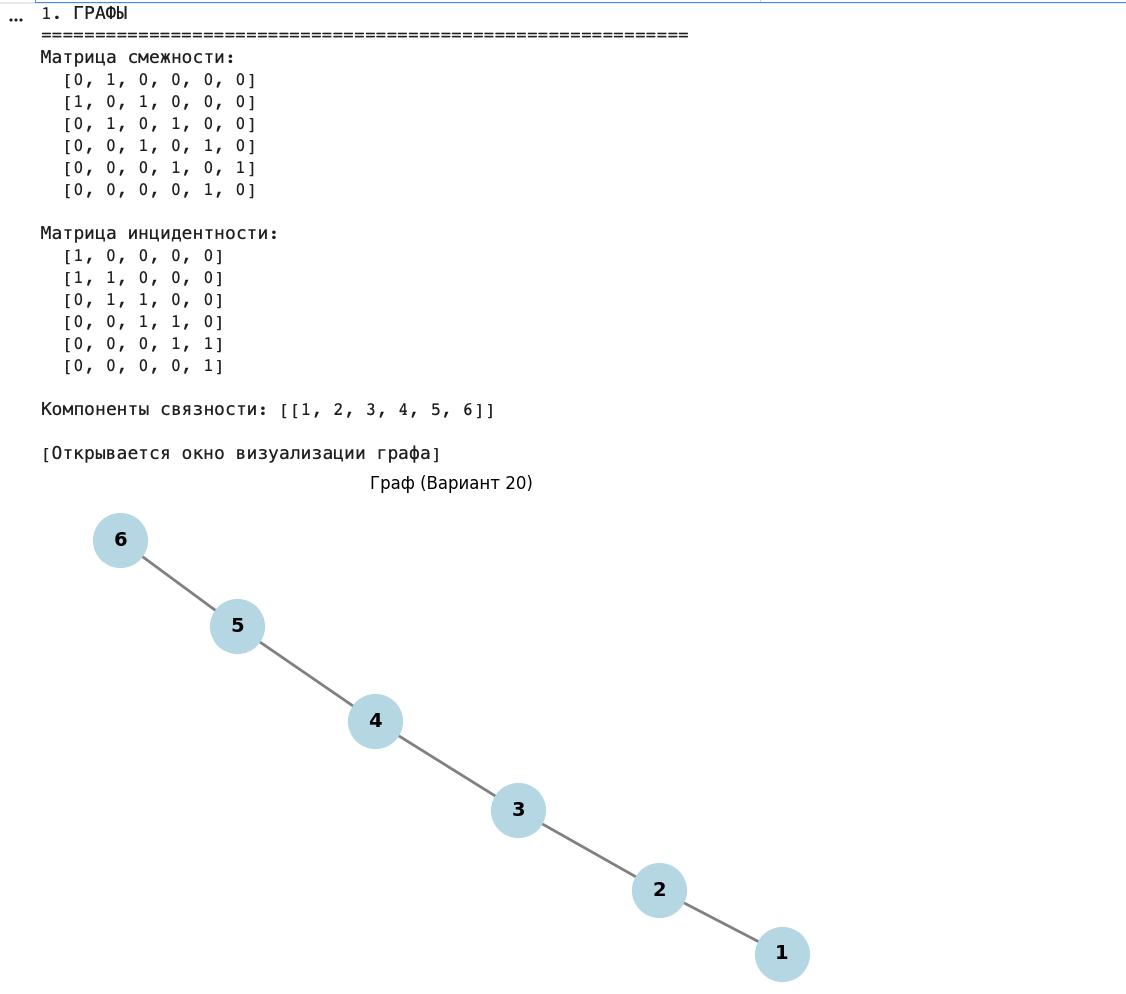![image.png]()

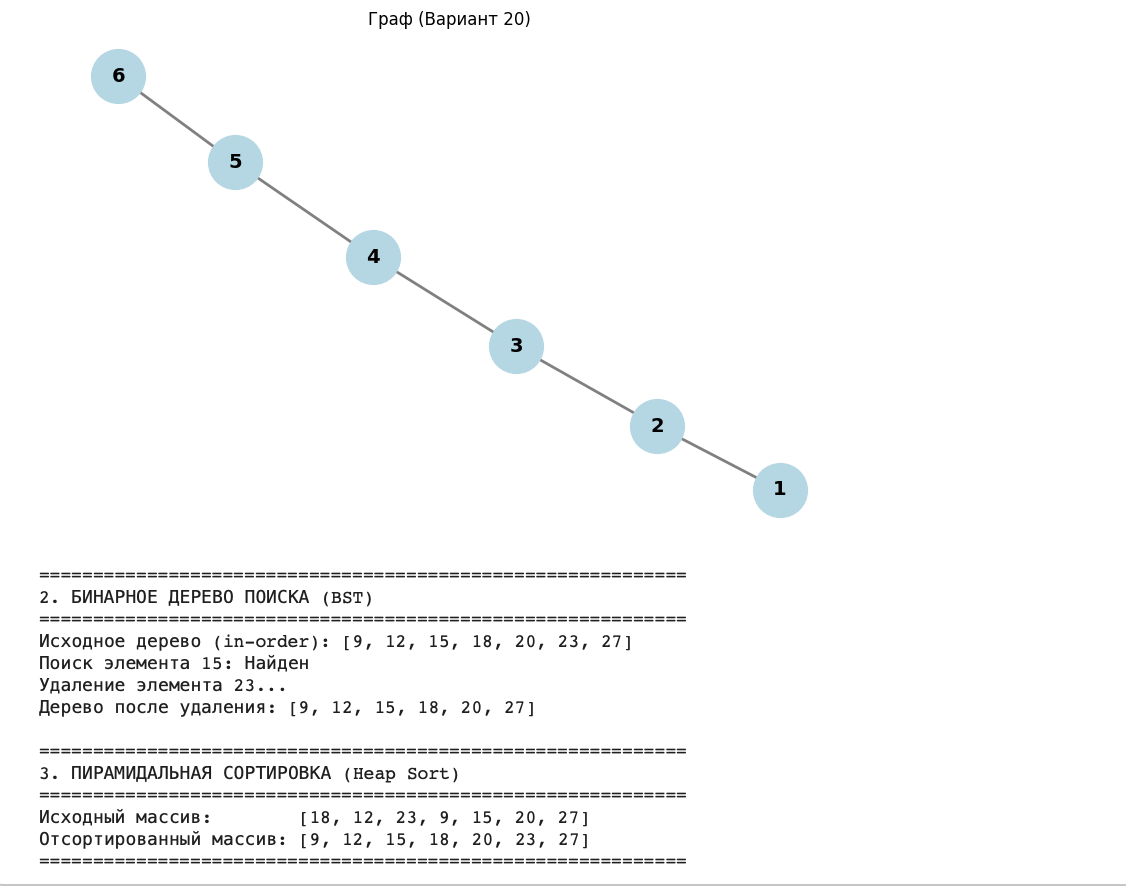